# Customer Retention Engine (PySpark)
## Churn Prediction & Revenue Risk Analysis — EMR Cluster Version
MSBX 5420 — Spring 2026

**To run on EMR cluster:** Use the PySpark kernel in JupyterHub and update DATA_PATH to your S3 location.

---

This notebook implements a full Customer Retention Engine using PySpark and Spark MLlib.
- **Dataset:** IBM Telco Customer Churn (7,043 rows, 21 columns)
- **Models:** Random Forest with CrossValidator for hyperparameter tuning
- **Outputs:** Churn risk scores, revenue at risk, retention ROI, segment analysis
- **Deployment:** Ready for AWS EMR cluster (includes S3 paths for production)


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

spark = SparkSession.builder \
    .appName("CustomerRetentionEngine") \
    .getOrCreate()

# LOCAL development: read from local file
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# EMR CLUSTER deployment: read from S3
# DATA_PATH = "s3://msbx5420-2026/teams/{team_directory}/WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Spark Session initialized")
print(f"Spark version: {spark.version}")


Spark Session initialized
Spark version: 4.1.1


## 1. Data Ingestion & Cleaning

Load the telco churn dataset, handle missing values, and prepare features for modeling.


In [4]:
# Load CSV with header and schema inference
df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

print("=== Original Data Schema ===")
df.printSchema()

print("\n=== Data Count ===")
print(f"Total rows: {df.count()}")

print("\n=== First 5 Rows ===")
df.show(5, truncate=False)

# Fix TotalCharges: trim whitespace, replace blanks with null, then cast to double
df = df.withColumn("TotalCharges", 
    F.when(F.trim(F.col("TotalCharges")) == "", None)
     .otherwise(F.trim(F.col("TotalCharges")))
     .cast("double"))

# Fill nulls with 0 (these are the 11 tenure=0 customers)
df = df.fillna({"TotalCharges": 0.0})

# Convert Churn from Yes/No to 1/0 numeric
df = df.withColumn("Churn_Numeric",
    F.when(F.col("Churn") == "Yes", 1).otherwise(0))

# Rename for clarity
df = df.withColumn("Churn_Label", F.col("Churn"))

print("\n=== Cleaned Data (first 5 rows) ===")
df.select("customerID", "Churn_Label", "Churn_Numeric", "TotalCharges", "tenure", "MonthlyCharges").show(5)


=== Original Data Schema ===
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)


=== Data Count ===
Total rows: 7043

=== First 5 Ro

In [5]:
print("=== Descriptive Statistics ===")
df.select("tenure", "MonthlyCharges", "TotalCharges").describe().show()

print("\n=== Churn Distribution ===")
churn_dist = df.groupBy("Churn_Label").count().collect()
for row in churn_dist:
    print(f"{row['Churn_Label']}: {row['count']}")

churn_rate = df.filter(F.col("Churn_Numeric") == 1).count() / df.count()
print(f"\nOverall Churn Rate: {churn_rate:.2%}")


=== Descriptive Statistics ===
+-------+------------------+------------------+------------------+
|summary|            tenure|    MonthlyCharges|      TotalCharges|
+-------+------------------+------------------+------------------+
|  count|              7043|              7043|              7043|
|   mean| 32.37114865824223| 64.76169246059922| 2279.734303563826|
| stddev|24.559481023094442|30.090047097678482|2266.7944696890245|
|    min|                 0|             18.25|               0.0|
|    max|                72|            118.75|            8684.8|
+-------+------------------+------------------+------------------+


=== Churn Distribution ===
No: 5174
Yes: 1869

Overall Churn Rate: 26.54%


## 2. Exploratory Data Analysis

Analyze churn patterns across key customer dimensions.


In [6]:
# Churn analysis by categorical features
categorical_features = ["Contract", "InternetService", "gender", "PaymentMethod", "TechSupport"]

print("=== Churn Rate by Feature ===\n")
for feature in categorical_features:
    feature_churn = df.groupBy(feature).agg(
        F.avg("Churn_Numeric").alias("churn_rate"),
        F.count("*").alias("count")
    ).orderBy(F.col("churn_rate").desc())
    
    print(f"\n{feature}:")
    feature_churn.show(truncate=False)

# Convert key features to pandas for visualization
contract_churn = df.groupBy("Contract").agg(
    F.avg("Churn_Numeric").alias("Churn_Rate"),
    F.count("*").alias("Count")
).toPandas().sort_values("Churn_Rate", ascending=False)

internet_churn = df.groupBy("InternetService").agg(
    F.avg("Churn_Numeric").alias("Churn_Rate"),
    F.count("*").alias("Count")
).toPandas().sort_values("Churn_Rate", ascending=False)

tech_support_churn = df.groupBy("TechSupport").agg(
    F.avg("Churn_Numeric").alias("Churn_Rate"),
    F.count("*").alias("Count")
).toPandas().sort_values("Churn_Rate", ascending=False)


=== Churn Rate by Feature ===


Contract:
+--------------+-------------------+-----+
|Contract      |churn_rate         |count|
+--------------+-------------------+-----+
|Month-to-month|0.4270967741935484 |3875 |
|One year      |0.11269517990495587|1473 |
|Two year      |0.02831858407079646|1695 |
+--------------+-------------------+-----+


InternetService:
+---------------+-------------------+-----+
|InternetService|churn_rate         |count|
+---------------+-------------------+-----+
|Fiber optic    |0.4189276485788114 |3096 |
|DSL            |0.1895910780669145 |2421 |
|No             |0.07404980340760157|1526 |
+---------------+-------------------+-----+


gender:
+------+-------------------+-----+
|gender|churn_rate         |count|
+------+-------------------+-----+
|Female|0.26920871559633025|3488 |
|Male  |0.2616033755274262 |3555 |
+------+-------------------+-----+


PaymentMethod:
+-------------------------+-------------------+-----+
|PaymentMethod            |churn_rate  

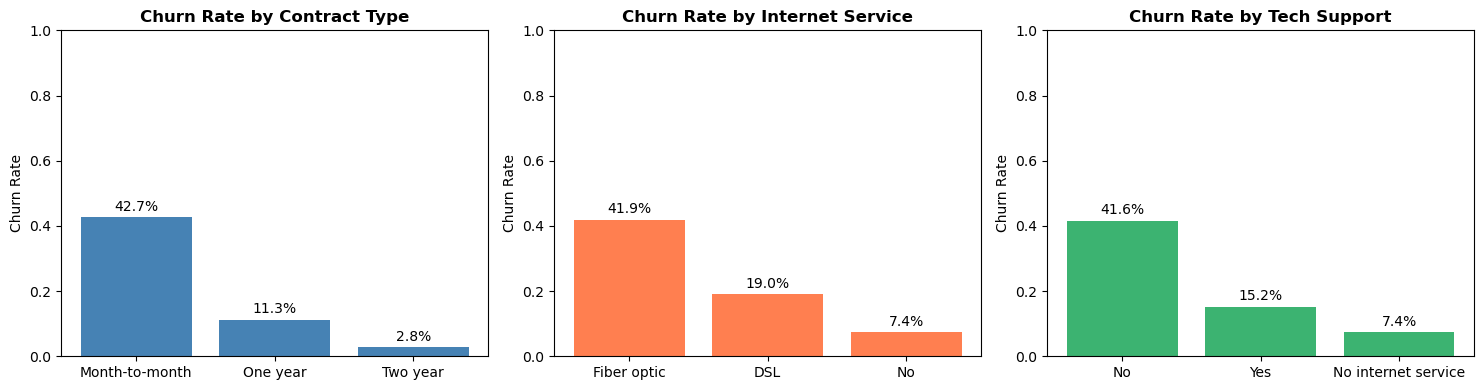

Visualization saved: 01_churn_by_features.png


In [7]:
# Create visualization of churn by key features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Contract
axes[0].bar(contract_churn["Contract"], contract_churn["Churn_Rate"], color="steelblue")
axes[0].set_title("Churn Rate by Contract Type", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Churn Rate")
axes[0].set_ylim([0, 1])
for i, v in enumerate(contract_churn["Churn_Rate"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)

# Internet Service
axes[1].bar(internet_churn["InternetService"], internet_churn["Churn_Rate"], color="coral")
axes[1].set_title("Churn Rate by Internet Service", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Churn Rate")
axes[1].set_ylim([0, 1])
for i, v in enumerate(internet_churn["Churn_Rate"]):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)

# Tech Support
axes[2].bar(tech_support_churn["TechSupport"], tech_support_churn["Churn_Rate"], color="mediumseagreen")
axes[2].set_title("Churn Rate by Tech Support", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Churn Rate")
axes[2].set_ylim([0, 1])
for i, v in enumerate(tech_support_churn["Churn_Rate"]):
    axes[2].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("01_churn_by_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("Visualization saved: 01_churn_by_features.png")


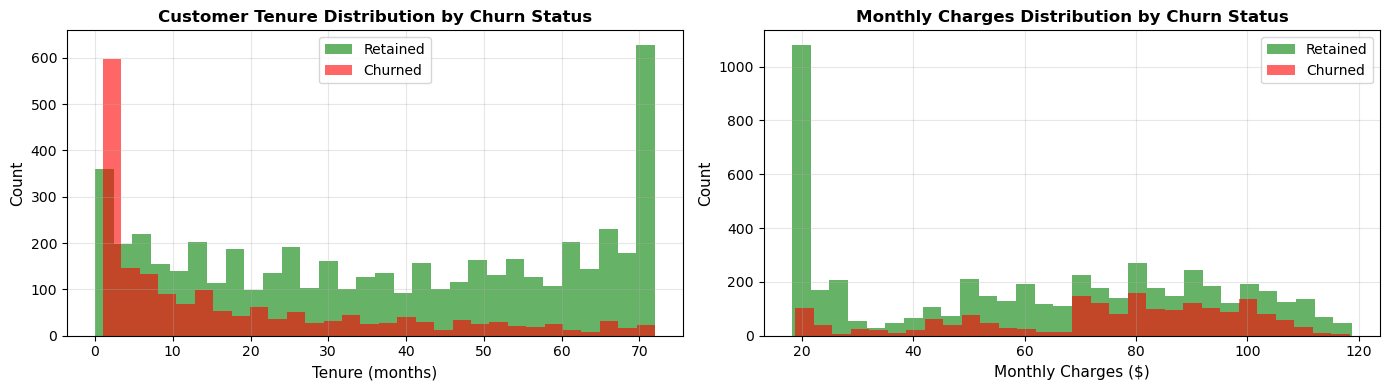

Visualization saved: 02_distributions_by_churn.png


In [8]:
# Tenure and MonthlyCharges distributions by churn status
df_pandas = df.select("tenure", "MonthlyCharges", "Churn_Label").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Tenure distribution
axes[0].hist(df_pandas[df_pandas["Churn_Label"] == "No"]["tenure"], 
             bins=30, alpha=0.6, label="Retained", color="green")
axes[0].hist(df_pandas[df_pandas["Churn_Label"] == "Yes"]["tenure"], 
             bins=30, alpha=0.6, label="Churned", color="red")
axes[0].set_xlabel("Tenure (months)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Customer Tenure Distribution by Churn Status", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Monthly Charges distribution
axes[1].hist(df_pandas[df_pandas["Churn_Label"] == "No"]["MonthlyCharges"], 
             bins=30, alpha=0.6, label="Retained", color="green")
axes[1].hist(df_pandas[df_pandas["Churn_Label"] == "Yes"]["MonthlyCharges"], 
             bins=30, alpha=0.6, label="Churned", color="red")
axes[1].set_xlabel("Monthly Charges ($)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Monthly Charges Distribution by Churn Status", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("02_distributions_by_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print("Visualization saved: 02_distributions_by_churn.png")


## 3. Feature Engineering

Build a PySpark ML pipeline for categorical encoding and feature vectorization.


In [9]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Define categorical and numeric columns
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")

# StringIndexer for each categorical column
indexers = [StringIndexer(inputCol=c, outputCol=c+"_Index", handleInvalid="keep") 
            for c in categorical_cols]

# OneHotEncoder for indexed columns
encoder = OneHotEncoder(inputCols=[c+"_Index" for c in categorical_cols],
                        outputCols=[c+"_OHE" for c in categorical_cols],
                        dropLast=False)

# VectorAssembler to combine all features
assembler_inputs = [c+"_OHE" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Build pipeline
pipeline = Pipeline(stages=indexers + [encoder, assembler])

print(f"\nPipeline stages: {len(pipeline.getStages())}")
print("Pipeline ready for fitting!")


Categorical features: 15
Numeric features: 4

Pipeline stages: 17
Pipeline ready for fitting!


In [10]:
# Fit pipeline and transform data
print("Fitting pipeline... (this may take a moment)")
pipeline_model = pipeline.fit(df)
df_transformed = pipeline_model.transform(df)

print("Pipeline fit complete!")
print(f"\nTransformed dataset shape: {df_transformed.count()} rows")
print(f"\nFeatures vector size: {len(df_transformed.select('features').take(1)[0][0])}")

# Train/test split (80/20)
train_df, test_df = df_transformed.randomSplit([0.8, 0.2], seed=42)
print(f"\nTraining set: {train_df.count()} rows ({train_df.count()/df_transformed.count():.1%})")
print(f"Test set: {test_df.count()} rows ({test_df.count()/df_transformed.count():.1%})")


Fitting pipeline... (this may take a moment)
Pipeline fit complete!

Transformed dataset shape: 7043 rows

Features vector size: 60

Training set: 5698 rows (80.9%)
Test set: 1345 rows (19.1%)


## 4. ML Model — Churn Risk Score & Key Churn Drivers

Train a Random Forest classifier with cross-validation hyperparameter tuning.


In [12]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

print("Initializing Random Forest Classifier...")
rf = RandomForestClassifier(labelCol="Churn_Numeric", featuresCol="features", seed=42)

# Hyperparameter grid for tuning
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [100, 200]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .addGrid(rf.minInstancesPerNode, [5, 10]) \
    .build()

print(f"Parameter grid size: {len(paramGrid)} combinations")

# Binary classification evaluator (AUC-ROC)
evaluator = BinaryClassificationEvaluator(labelCol="Churn_Numeric", metricName="areaUnderROC")

# CrossValidator with 5-fold cross-validation
cv = CrossValidator(estimator=rf, estimatorParamMaps=paramGrid,
                    evaluator=evaluator, numFolds=5, seed=42, parallelism=4)

print("\nFitting CrossValidator... (this will take several minutes on local Spark)")
cv_model = cv.fit(train_df)

best_model = cv_model.bestModel
print(f"\nCrossValidator complete!")
print(f"Best numTrees: {best_model.getNumTrees}")
print(f"Best maxDepth: {best_model.getOrDefault('maxDepth')}")
print(f"Best minInstancesPerNode: {best_model.getOrDefault('minInstancesPerNode')}")


Initializing Random Forest Classifier...
Parameter grid size: 8 combinations

Fitting CrossValidator... (this will take several minutes on local Spark)

CrossValidator complete!
Best numTrees: 200
Best maxDepth: 10
Best minInstancesPerNode: 5


In [13]:
# Predictions on test set
print("Evaluating on test set...")
predictions = cv_model.transform(test_df)

# AUC-ROC
auc_score = evaluator.evaluate(predictions)
print(f"\nTest AUC-ROC: {auc_score:.4f}")

# Accuracy, Precision, Recall, F1
multi_eval = MulticlassClassificationEvaluator(labelCol="Churn_Numeric", predictionCol="prediction")
metrics = {}
for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    multi_eval.setMetricName(metric_name)
    score = multi_eval.evaluate(predictions)
    metrics[metric_name] = score
    print(f"{metric_name}: {score:.4f}")

print("\n=== Model Performance Summary ===")
print(f"AUC-ROC: {auc_score:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['weightedPrecision']:.4f}")
print(f"Recall: {metrics['weightedRecall']:.4f}")
print(f"F1-Score: {metrics['f1']:.4f}")


Evaluating on test set...

Test AUC-ROC: 0.8453
accuracy: 0.8000
weightedPrecision: 0.7892
weightedRecall: 0.8000
f1: 0.7877

=== Model Performance Summary ===
AUC-ROC: 0.8453
Accuracy: 0.8000
Precision: 0.7892
Recall: 0.8000
F1-Score: 0.7877


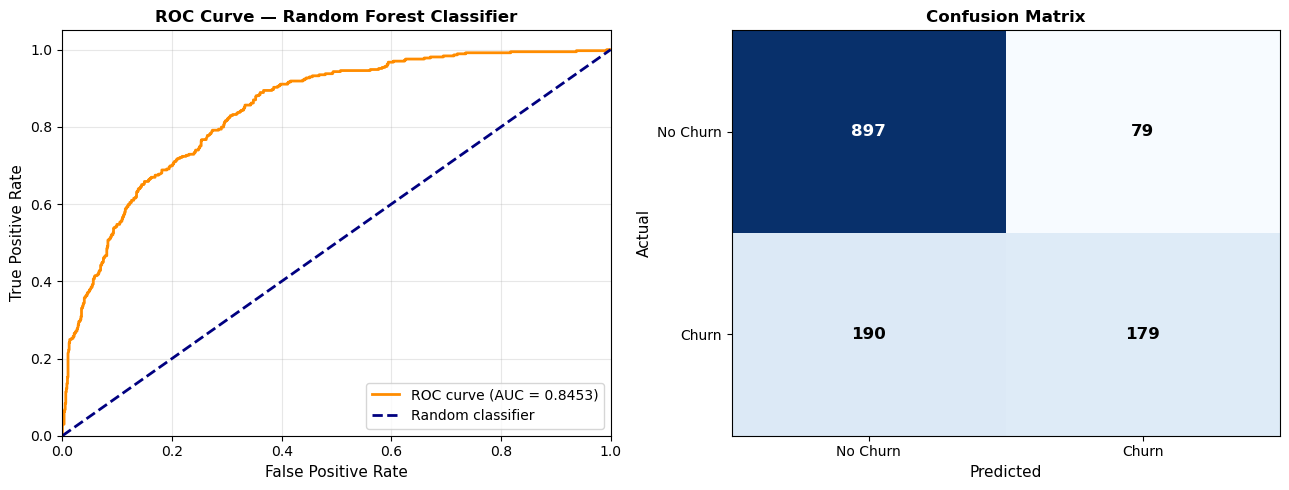

Confusion Matrix:
  TN: 897, FP: 79
  FN: 190, TP: 179

Visualization saved: 03_roc_curve_confusion_matrix.png


In [14]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Convert predictions to pandas for sklearn metrics
predictions_pd = predictions.select("Churn_Numeric", "probability").toPandas()

# Extract probability of churn (class 1)
predictions_pd["churn_prob"] = predictions_pd["probability"].apply(lambda x: x[1])
y_true = predictions_pd["Churn_Numeric"].values
y_proba = predictions_pd["churn_prob"].values

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

# Calculate confusion matrix
cm = confusion_matrix(y_true, (y_proba >= 0.5).astype(int))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curve — Random Forest Classifier", fontsize=12, fontweight="bold")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Confusion Matrix
im = axes[1].imshow(cm, cmap="Blues", aspect="auto")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["No Churn", "Churn"])
axes[1].set_yticklabels(["No Churn", "Churn"])
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("Actual", fontsize=11)
axes[1].set_title("Confusion Matrix", fontsize=12, fontweight="bold")

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center", 
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("03_roc_curve_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Confusion Matrix:")
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TP: {cm[1,1]}")
print(f"\nVisualization saved: 03_roc_curve_confusion_matrix.png")


In [15]:
# Score all customers
print("Scoring all customers...")
all_predictions = cv_model.transform(df_transformed)

# Extract churn probability (probability of class 1)
extract_prob = F.udf(lambda v: float(v[1]), DoubleType())
scored_df = all_predictions.withColumn("Churn_Risk_Score", extract_prob(F.col("probability")))

# Create risk tiers based on churn probability
scored_df = scored_df.withColumn("Risk_Tier",
    F.when(F.col("Churn_Risk_Score") >= 0.7, "High")
     .when(F.col("Churn_Risk_Score") >= 0.3, "Medium")
     .otherwise("Low"))

print("\n=== Risk Tier Distribution ===")
risk_dist = scored_df.groupBy("Risk_Tier").count().collect()
for row in sorted(risk_dist, key=lambda x: {"High": 0, "Medium": 1, "Low": 2}[x["Risk_Tier"]]):
    print(f"{row['Risk_Tier']}: {row['count']} customers")

print("\n=== Sample Scored Customers ===")
scored_df.select("customerID", "Churn_Risk_Score", "Risk_Tier", "Churn_Label").show(10)


Scoring all customers...

=== Risk Tier Distribution ===
High: 428 customers
Medium: 2134 customers
Low: 4481 customers

=== Sample Scored Customers ===
+----------+--------------------+---------+-----------+
|customerID|    Churn_Risk_Score|Risk_Tier|Churn_Label|
+----------+--------------------+---------+-----------+
|7590-VHVEG|  0.6434584620081719|   Medium|         No|
|5575-GNVDE| 0.06188986330896815|      Low|         No|
|3668-QPYBK|  0.4028214556542856|   Medium|        Yes|
|7795-CFOCW|0.058426165511471055|      Low|         No|
|9237-HQITU|  0.6633403032128813|   Medium|        Yes|
|9305-CDSKC|  0.7717842745922079|     High|        Yes|
|1452-KIOVK| 0.36390672208440455|   Medium|         No|
|6713-OKOMC|   0.219370045736902|      Low|         No|
|7892-POOKP| 0.49731767523585435|   Medium|        Yes|
|6388-TABGU| 0.05618059295571223|      Low|         No|
+----------+--------------------+---------+-----------+
only showing top 10 rows


Extracting feature importance...
Total features: 60, Total importances: 60

=== Top 20 Feature Importances ===
                                Feature  Importance
                                 tenure    0.139726
            Contract_OHE_Month-to-month    0.132615
                           TotalCharges    0.104793
                  OnlineSecurity_OHE_No    0.055408
                         MonthlyCharges    0.055007
        InternetService_OHE_Fiber optic    0.051863
     PaymentMethod_OHE_Electronic check    0.048626
                  Contract_OHE_Two year    0.045860
                     TechSupport_OHE_No    0.045633
                    OnlineBackup_OHE_No    0.024240
                InternetService_OHE_DSL    0.022086
                  Contract_OHE_One year    0.018415
                DeviceProtection_OHE_No    0.016063
                    TechSupport_OHE_Yes    0.016018
                 OnlineSecurity_OHE_Yes    0.015423
                   OnlineBackup_OHE_Yes    0.012390
     

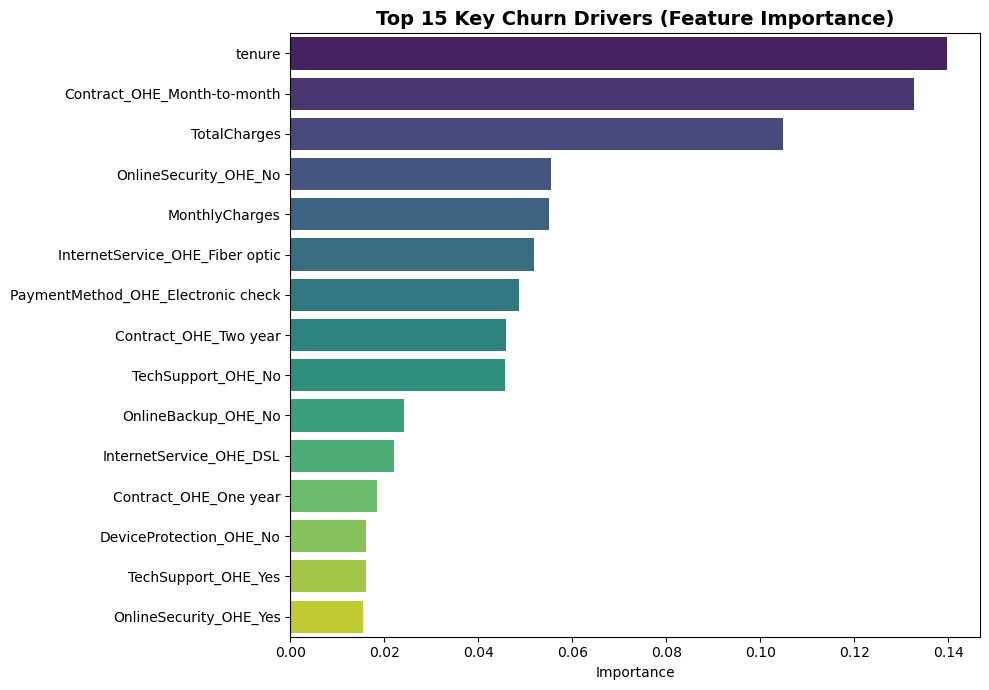


Visualization saved: 04_feature_importance_pyspark.png


In [18]:
import numpy as np

print("Extracting feature importance...")

# Get feature importances
importances = best_model.featureImportances.toArray()

# Get feature names directly from VectorAssembler metadata
attrs = sorted(
    (attr["idx"], attr["name"])
    for attr_type_key, attr_type_val in df_transformed.schema["features"].metadata["ml_attr"]["attrs"].items()
    for attr in attr_type_val
)
feature_names = [name for idx, name in attrs]

print(f"Total features: {len(feature_names)}, Total importances: {len(importances)}")

# Create DataFrame with feature importances
fi_df = pd.DataFrame({
    "Feature": feature_names[:len(importances)],
    "Importance": importances
})
fi_df = fi_df.sort_values("Importance", ascending=False)

print("\n=== Top 20 Feature Importances ===")
print(fi_df.head(20).to_string(index=False))

# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 7))
top_15 = fi_df.head(15)
sns.barplot(data=top_15, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False, ax=ax)
ax.set_title("Top 15 Key Churn Drivers (Feature Importance)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("04_feature_importance_pyspark.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nVisualization saved: 04_feature_importance_pyspark.png")

## 5. Business Metrics — CLV, Revenue at Risk, Retention ROI

Calculate customer lifetime value, revenue at risk, and return on investment for retention campaigns.


In [23]:
# Historical CLV = tenure * MonthlyCharges
scored_df = scored_df.withColumn("CLV_Historical", 
    F.col("tenure") * F.col("MonthlyCharges"))

# Projected CLV: use average tenure of non-churners as expected lifetime
print("Calculating projected CLV...")
avg_tenure_non_churn = df.filter(F.col("Churn_Numeric") == 0).agg(F.avg("tenure")).collect()[0][0]
print(f"Average tenure of non-churners: {avg_tenure_non_churn:.1f} months")

scored_df = scored_df.withColumn("CLV_Projected",
    F.col("MonthlyCharges") * F.lit(float(avg_tenure_non_churn)))

# Revenue at Risk = CLV_Projected * Churn_Risk_Score
scored_df = scored_df.withColumn("Revenue_at_Risk",
    F.col("CLV_Projected") * F.col("Churn_Risk_Score"))

print("\n=== Top 20 Customers by Revenue at Risk ===")
scored_df.select("customerID", "Churn_Risk_Score", "Risk_Tier", 
                  "CLV_Historical", "CLV_Projected", "Revenue_at_Risk", "tenure", "MonthlyCharges") \
         .orderBy(F.col("Revenue_at_Risk").desc()).show(20, truncate=False)

# Summary stats
total_clv = scored_df.agg(F.sum("CLV_Projected")).collect()[0][0]
total_rar = scored_df.agg(F.sum("Revenue_at_Risk")).collect()[0][0]
print(f"\nTotal Projected CLV: ${total_clv:,.0f}")
print(f"Total Revenue at Risk: ${total_rar:,.0f}")


Calculating projected CLV...
Average tenure of non-churners: 37.6 months

=== Top 20 Customers by Revenue at Risk ===
+----------+------------------+---------+------------------+------------------+------------------+------+--------------+
|customerID|Churn_Risk_Score  |Risk_Tier|CLV_Historical    |CLV_Projected     |Revenue_at_Risk   |tenure|MonthlyCharges|
+----------+------------------+---------+------------------+------------------+------------------+------+--------------+
|5419-JPRRN|0.8598543749099703|High     |101.45            |3811.4729706223425|3277.311708640722 |1     |101.45        |
|7216-EWTRS|0.8335919490129121|High     |100.8             |3787.0524932354074|3156.8564688503116|1     |100.8         |
|1400-MMYXY|0.7880993688055835|High     |317.70000000000005|3978.6593158098185|3135.578895482173 |3     |105.9         |
|0107-YHINA|0.8329706311888868|High     |99.75             |3747.6040297642053|3121.6440941187057|1     |99.75         |
|6023-YEBUP|0.8213152636705433|High

In [24]:
# Campaign economics
CAMPAIGN_COST_PER_CUSTOMER = 50
PREVENTION_RATE = 0.50  # Assume 50% of at-risk customers can be retained

print("=== Campaign Economics ===")
print(f"Campaign cost per customer: ${CAMPAIGN_COST_PER_CUSTOMER}")
print(f"Prevention rate (assumption): {PREVENTION_RATE:.0%}")
print()

# ROI for targeting HIGH-RISK customers only
high_risk = scored_df.filter(F.col("Risk_Tier") == "High")
high_risk_count = high_risk.count()
high_risk_revenue = high_risk.agg(F.sum("Revenue_at_Risk")).collect()[0][0] or 0
high_risk_saved = high_risk_revenue * PREVENTION_RATE
high_risk_cost = high_risk_count * CAMPAIGN_COST_PER_CUSTOMER
high_risk_roi = (high_risk_saved - high_risk_cost) / high_risk_cost if high_risk_cost > 0 else 0

# ROI for targeting ALL customers
all_count = scored_df.count()
all_revenue = scored_df.agg(F.sum("Revenue_at_Risk")).collect()[0][0] or 0
all_saved = all_revenue * PREVENTION_RATE
all_cost = all_count * CAMPAIGN_COST_PER_CUSTOMER
all_roi = (all_saved - all_cost) / all_cost if all_cost > 0 else 0

print("=== Targeted Campaign (High-Risk Only) ===")
print(f"Customers targeted: {high_risk_count:,}")
print(f"Campaign cost: ${high_risk_cost:,.0f}")
print(f"Revenue at Risk: ${high_risk_revenue:,.0f}")
print(f"Revenue saved (50% retention): ${high_risk_saved:,.0f}")
print(f"Net Benefit: ${high_risk_saved - high_risk_cost:,.0f}")
print(f"ROI: {high_risk_roi:.1%}")

print()
print("=== Broad Campaign (All Customers) ===")
print(f"Customers targeted: {all_count:,}")
print(f"Campaign cost: ${all_cost:,.0f}")
print(f"Revenue at Risk: ${all_revenue:,.0f}")
print(f"Revenue saved (50% retention): ${all_saved:,.0f}")
print(f"Net Benefit: ${all_saved - all_cost:,.0f}")
print(f"ROI: {all_roi:.1%}")

print()
print("=== Recommendation ===")
if high_risk_roi > all_roi:
    print(f"TARGETED approach is more cost-effective (+{(high_risk_roi - all_roi):.1%} better ROI)")
else:
    print(f"BROAD approach offers better ROI (+{(all_roi - high_risk_roi):.1%} better ROI)")


=== Campaign Economics ===
Campaign cost per customer: $50
Prevention rate (assumption): 50%

=== Targeted Campaign (High-Risk Only) ===
Customers targeted: 428
Campaign cost: $21,400
Revenue at Risk: $968,737
Revenue saved (50% retention): $484,369
Net Benefit: $462,969
ROI: 2163.4%

=== Broad Campaign (All Customers) ===
Customers targeted: 7,043
Campaign cost: $352,150
Revenue at Risk: $5,102,234
Revenue saved (50% retention): $2,551,117
Net Benefit: $2,198,967
ROI: 624.4%

=== Recommendation ===
TARGETED approach is more cost-effective (+1539.0% better ROI)


## 6. Group Segmentation Analysis

Analyze churn risk, CLV, and revenue at risk across key customer segments.


In [25]:
# Segment analysis by Gender
gender_metrics = scored_df.groupBy("gender").agg(
    F.avg("CLV_Projected").alias("Avg_CLV"),
    F.sum("Revenue_at_Risk").alias("Total_Revenue_at_Risk"),
    F.avg("Churn_Risk_Score").alias("Avg_Churn_Risk"),
    F.count("*").alias("Count")
).toPandas()
gender_metrics = gender_metrics.sort_values("Avg_CLV", ascending=False)

print("=== Metrics by Gender ===")
print(gender_metrics.to_string(index=False))

# Segment analysis by Senior Citizen status
senior_metrics = scored_df.groupBy("SeniorCitizen").agg(
    F.avg("CLV_Projected").alias("Avg_CLV"),
    F.sum("Revenue_at_Risk").alias("Total_Revenue_at_Risk"),
    F.avg("Churn_Risk_Score").alias("Avg_Churn_Risk"),
    F.count("*").alias("Count")
).toPandas()
senior_metrics["Senior_Status"] = senior_metrics["SeniorCitizen"].map({0: "No", 1: "Yes"})
senior_metrics = senior_metrics[["Senior_Status", "Avg_CLV", "Total_Revenue_at_Risk", "Avg_Churn_Risk", "Count"]]

print("\n=== Metrics by Senior Citizen Status ===")
print(senior_metrics.to_string(index=False))

# Segment analysis by Contract type
contract_metrics = scored_df.groupBy("Contract").agg(
    F.avg("CLV_Projected").alias("Avg_CLV"),
    F.sum("Revenue_at_Risk").alias("Total_Revenue_at_Risk"),
    F.avg("Churn_Risk_Score").alias("Avg_Churn_Risk"),
    F.count("*").alias("Count")
).toPandas()
contract_metrics = contract_metrics.sort_values("Avg_CLV", ascending=False)

print("\n=== Metrics by Contract Type ===")
print(contract_metrics.to_string(index=False))


=== Metrics by Gender ===
gender     Avg_CLV  Total_Revenue_at_Risk  Avg_Churn_Risk  Count
Female 2449.721146           2.566326e+06        0.265445   3488
  Male 2416.781277           2.535908e+06        0.260466   3555

=== Metrics by Senior Citizen Status ===
Senior_Status     Avg_CLV  Total_Revenue_at_Risk  Avg_Churn_Risk  Count
          Yes 2998.848111           1.355765e+06        0.390920   1142
           No 2323.606211           3.746469e+06        0.238163   5901

=== Metrics by Contract Type ===
      Contract     Avg_CLV  Total_Revenue_at_Risk  Avg_Churn_Risk  Count
Month-to-month 2494.588971           4.386821e+06        0.414844   3875
      One year 2443.873950           5.175359e+05        0.117820   1473
      Two year 2283.142301           1.978766e+05        0.041747   1695


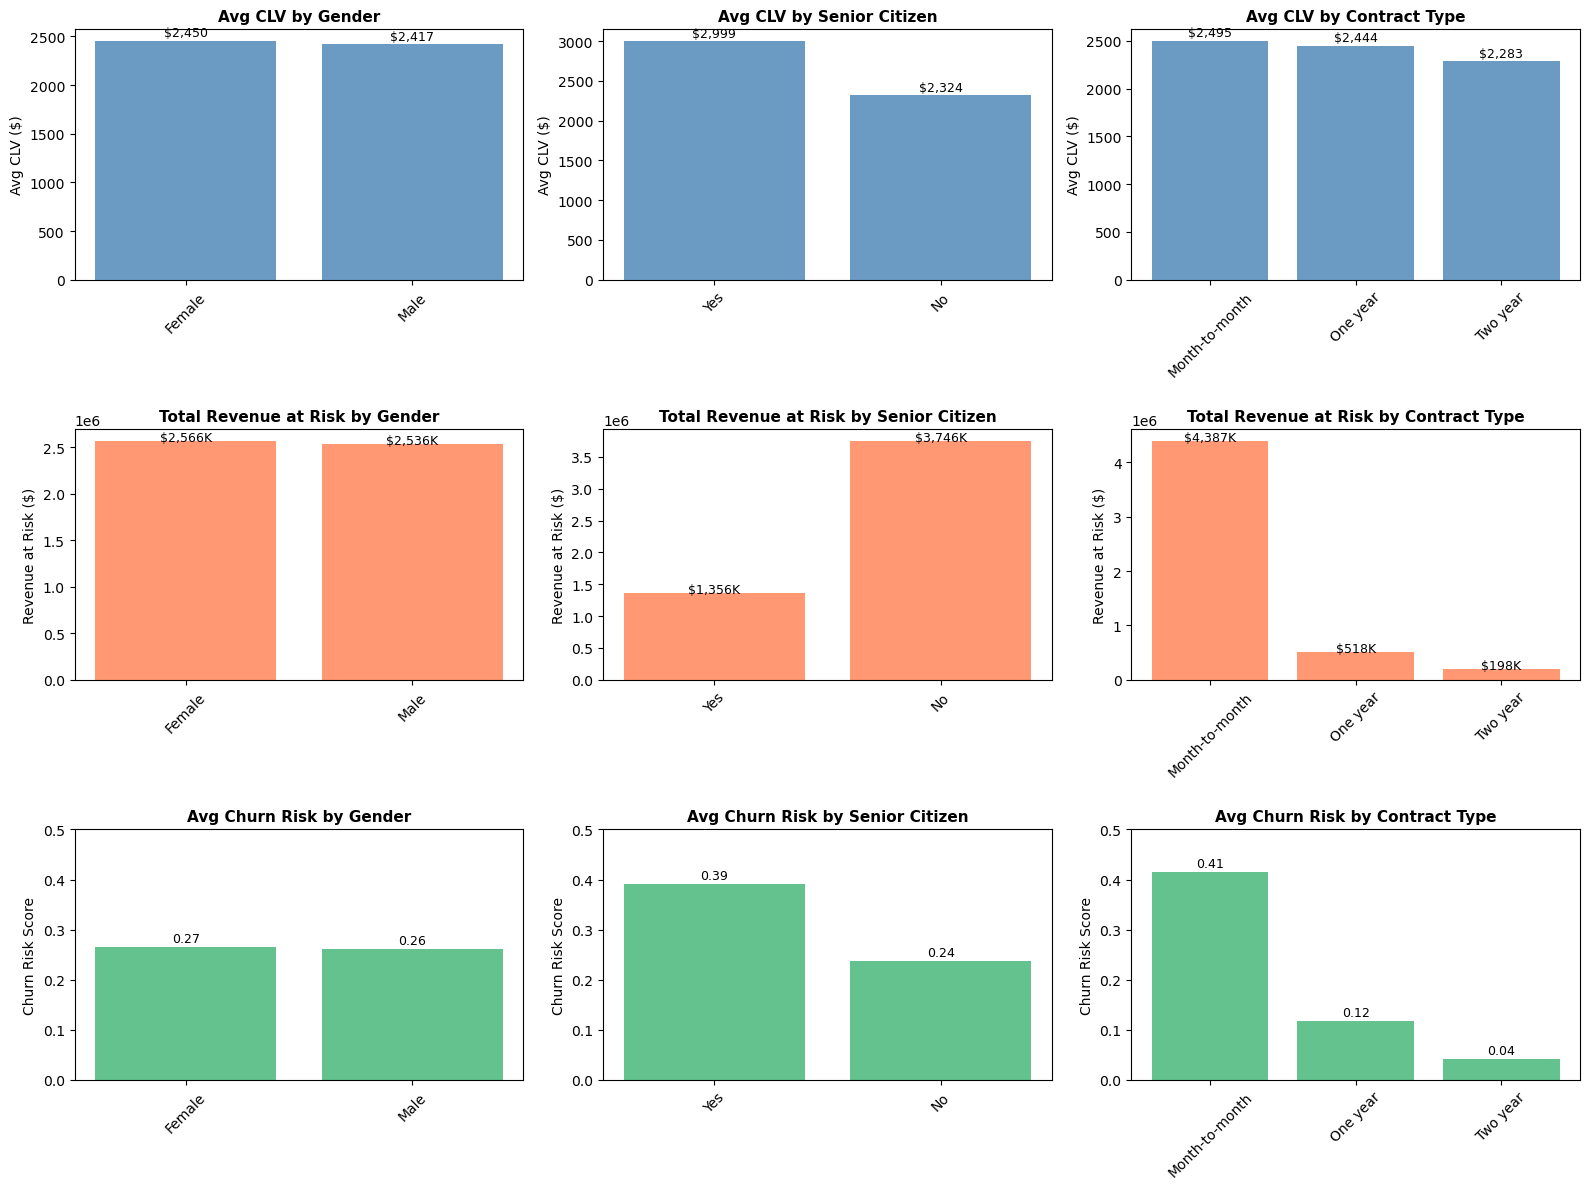

Visualization saved: 05_segmentation_analysis_pyspark.png


In [26]:
# Create 3x3 grid visualization: segmentation analysis
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

segments = {
    "gender": gender_metrics,
    "Senior_Status": senior_metrics,
    "Contract": contract_metrics
}

segment_labels = ["Gender", "Senior Citizen", "Contract Type"]

# Row 1: Avg CLV
for col, (seg_name, seg_data) in enumerate(segments.items()):
    label_col = list(seg_data.columns)[0]
    axes[0, col].bar(seg_data[label_col], seg_data["Avg_CLV"], color="steelblue", alpha=0.8)
    axes[0, col].set_title(f"Avg CLV by {segment_labels[col]}", fontsize=11, fontweight="bold")
    axes[0, col].set_ylabel("Avg CLV ($)")
    axes[0, col].tick_params(axis="x", rotation=45)
    for i, v in enumerate(seg_data["Avg_CLV"]):
        axes[0, col].text(i, v + 50, f"${v:,.0f}", ha="center", fontsize=9)

# Row 2: Total Revenue at Risk
for col, (seg_name, seg_data) in enumerate(segments.items()):
    label_col = list(seg_data.columns)[0]
    axes[1, col].bar(seg_data[label_col], seg_data["Total_Revenue_at_Risk"], color="coral", alpha=0.8)
    axes[1, col].set_title(f"Total Revenue at Risk by {segment_labels[col]}", fontsize=11, fontweight="bold")
    axes[1, col].set_ylabel("Revenue at Risk ($)")
    axes[1, col].tick_params(axis="x", rotation=45)
    for i, v in enumerate(seg_data["Total_Revenue_at_Risk"]):
        axes[1, col].text(i, v + 500, f"${v/1000:,.0f}K", ha="center", fontsize=9)

# Row 3: Avg Churn Risk
for col, (seg_name, seg_data) in enumerate(segments.items()):
    label_col = list(seg_data.columns)[0]
    axes[2, col].bar(seg_data[label_col], seg_data["Avg_Churn_Risk"], color="mediumseagreen", alpha=0.8)
    axes[2, col].set_title(f"Avg Churn Risk by {segment_labels[col]}", fontsize=11, fontweight="bold")
    axes[2, col].set_ylabel("Churn Risk Score")
    axes[2, col].set_ylim([0, 0.5])
    axes[2, col].tick_params(axis="x", rotation=45)
    for i, v in enumerate(seg_data["Avg_Churn_Risk"]):
        axes[2, col].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("05_segmentation_analysis_pyspark.png", dpi=150, bbox_inches="tight")
plt.show()

print("Visualization saved: 05_segmentation_analysis_pyspark.png")


## 7. Executive Dashboard Summary

Key metrics and priority targets for retention action.


In [27]:
# Create priority score: Churn_Risk_Score * CLV_Projected
priority_df = scored_df.withColumn("Priority_Score", 
    F.col("Churn_Risk_Score") * F.col("CLV_Projected"))

print("=== TOP 20 PRIORITY TARGETS ===")
print("\n(Customers ranked by Priority Score = Churn Risk * CLV)")
print()

top_20 = priority_df.select(
    "customerID", "Churn_Risk_Score", "Risk_Tier", 
    "CLV_Projected", "Revenue_at_Risk", "Priority_Score",
    "Contract", "tenure", "MonthlyCharges"
).orderBy(F.col("Priority_Score").desc()).limit(20)

top_20_pd = top_20.toPandas()
print(top_20_pd.to_string(index=False))


=== TOP 20 PRIORITY TARGETS ===

(Customers ranked by Priority Score = Churn Risk * CLV)

customerID  Churn_Risk_Score Risk_Tier  CLV_Projected  Revenue_at_Risk  Priority_Score       Contract  tenure  MonthlyCharges
5419-JPRRN          0.859854      High    3811.472971      3277.311709     3277.311709 Month-to-month       1          101.45
7216-EWTRS          0.833592      High    3787.052493      3156.856469     3156.856469 Month-to-month       1          100.80
1400-MMYXY          0.788099      High    3978.659316      3135.578895     3135.578895 Month-to-month       3          105.90
0107-YHINA          0.832971      High    3747.604030      3121.644094     3121.644094 Month-to-month       1           99.75
6023-YEBUP          0.821315      High    3792.687988      3114.992535     3114.992535 Month-to-month       3          100.95
6496-SLWHQ          0.784024      High    3944.846347      3092.852618     3092.852618 Month-to-month       3          105.00
5299-SJCZT          0.810006

In [28]:
print("=" * 70)
print(" " * 15 + "CUSTOMER RETENTION ENGINE — EXECUTIVE SUMMARY")
print("=" * 70)

total = scored_df.count()
churn_rate = scored_df.agg(F.avg("Churn_Numeric")).collect()[0][0]
high = scored_df.filter(F.col("Risk_Tier") == "High").count()
medium = scored_df.filter(F.col("Risk_Tier") == "Medium").count()
low = scored_df.filter(F.col("Risk_Tier") == "Low").count()
total_clv = scored_df.agg(F.sum("CLV_Projected")).collect()[0][0]
total_rev_risk = scored_df.agg(F.sum("Revenue_at_Risk")).collect()[0][0]

print()
print(f"  Total Customers Analyzed:        {total:>12,}")
print(f"  Historical Churn Rate:           {churn_rate:>12.1%}")
print()
print("  Risk Distribution:")
print(f"    • High Risk (≥70% churn prob):   {high:>10,} customers")
print(f"    • Medium Risk (30-70%):          {medium:>10,} customers")
print(f"    • Low Risk (<30%):               {low:>10,} customers")
print()
print(f"  Total Projected CLV:             ${total_clv:>16,.0f}")
print(f"  Total Revenue at Risk:           ${total_rev_risk:>16,.0f}")
print()
print(f"  Targeted Retention Campaign ROI: {high_risk_roi:>12.1%}")
print(f"  Potential Revenue Save:          ${high_risk_saved:>16,.0f}")
print()
print("=" * 70)
print()
print("RECOMMENDATION:")
if high_risk_roi > 0:
    print(f"  Launch TARGETED retention campaign for {high} high-risk customers")
    print(f"  Expected ROI: {high_risk_roi:.1%} | Net Benefit: ${high_risk_saved - high_risk_cost:,.0f}")
else:
    print("  Caution: ROI is negative. Review campaign cost assumptions.")
print()
print("=" * 70)


               CUSTOMER RETENTION ENGINE — EXECUTIVE SUMMARY

  Total Customers Analyzed:               7,043
  Historical Churn Rate:                  26.5%

  Risk Distribution:
    • High Risk (≥70% churn prob):          428 customers
    • Medium Risk (30-70%):               2,134 customers
    • Low Risk (<30%):                    4,481 customers

  Total Projected CLV:             $      17,136,285
  Total Revenue at Risk:           $       5,102,234

  Targeted Retention Campaign ROI:      2163.4%
  Potential Revenue Save:          $         484,369


RECOMMENDATION:
  Launch TARGETED retention campaign for 428 high-risk customers
  Expected ROI: 2163.4% | Net Benefit: $462,969



In [29]:
print("Saving outputs...")

# Create output directories if needed
import os
os.makedirs("customer_scores_parquet", exist_ok=True)
os.makedirs("customer_scores_csv", exist_ok=True)

# Select final columns for export
export_cols = ["customerID", "gender", "SeniorCitizen", "Contract", "tenure",
               "MonthlyCharges", "TotalCharges", "Churn_Risk_Score", "Risk_Tier",
               "CLV_Historical", "CLV_Projected", "Revenue_at_Risk"]

output_df = scored_df.select(export_cols)

# Save as Parquet (efficient for Spark)
print("\nSaving as Parquet...")
output_df.coalesce(1).write.mode("overwrite").parquet("customer_scores_parquet")

# EMR CLUSTER: uncomment and update S3 path
# output_df.write.mode("overwrite").parquet("s3://msbx5420-2026/teams/{team_directory}/customer_scores_parquet")

# Also save as CSV for easy viewing
print("Saving as CSV...")
output_df.coalesce(1).write.mode("overwrite").option("header", True).csv("customer_scores_csv")

# EMR CLUSTER: uncomment and update S3 path
# output_df.coalesce(1).write.mode("overwrite").option("header", True).csv("s3://msbx5420-2026/teams/{team_directory}/customer_scores_csv")

print("\nOutputs saved!")
print("  • Parquet: customer_scores_parquet/")
print("  • CSV: customer_scores_csv/")
print("\nModel artifacts:")
print("  • 01_churn_by_features.png")
print("  • 02_distributions_by_churn.png")
print("  • 03_roc_curve_confusion_matrix.png")
print("  • 04_feature_importance_pyspark.png")
print("  • 05_segmentation_analysis_pyspark.png")

# Clean up Spark session
print("\nStopping Spark session...")
spark.stop()
print("Done!")


Saving outputs...

Saving as Parquet...
Saving as CSV...

Outputs saved!
  • Parquet: customer_scores_parquet/
  • CSV: customer_scores_csv/

Model artifacts:
  • 01_churn_by_features.png
  • 02_distributions_by_churn.png
  • 03_roc_curve_confusion_matrix.png
  • 04_feature_importance_pyspark.png
  • 05_segmentation_analysis_pyspark.png

Stopping Spark session...
Done!
